## **Name:  Remy Gundona**
## **Roll no: 2000250064**

# **Predicting Customer Credit Default: A Comparative Statistical Study of PCA and Logistic Regression in Commercial Banking**

### **Project Overview:**

This project focuses on developing and evaluating a machine learning model for **credit risk classification**. The objective is to predict whether a loan applicant should be classified as:

- **Good Credit Risk (0)**  
- **Bad Credit Risk (1)**  

Accurate credit risk prediction is critical for financial institutions, as it directly impacts loan approval decisions, risk management, profitability, and regulatory compliance.



### **Problem Statement:**

Credit risk modeling is inherently a **binary classification problem** with class imbalance, where defaulters (Bad credit risks) typically represent a smaller proportion of applicants.

The key challenge is to:

- Accurately identify high-risk borrowers (minimize False Negatives),  
- While avoiding unnecessary rejection of creditworthy applicants (minimize False Positives).

This project evaluates how well a machine learning model balances these competing objectives.



### **Objectives:**

The main goals of this project are:

1. **Data Exploration & Preprocessing**
   - Understand feature distributions
   - Identify key relationships with the target variable
   - Handle categorical variables and data preparation

2. **Normality Testing**
    - Test for normality using P-P plot. Q-Q plots and Shapiro-wilks

3. **Dimensionality Reduction**
    - Perform a dimensionality reduction using PCA to reduce the dimensionality of the dataset.

4. **Model Development**
   - Train a binary classification model
   - Generate probability predictions
   - Optimize classification thresholds

5. **Model Evaluation**
   - Analyze performance using:
     - Confusion Matrix
     - Precision, Recall, F1-Score
     - ROC Curve (AUC-ROC)
     - Precision–Recall Curve (AUC-PR)
   - Interpret trade-offs between sensitivity and precision

6. **Business Interpretation**
   - Translate statistical results into financial risk implications
   - Assess the cost of False Negatives (missed defaulters)
   - Assess the cost of False Positives (lost good customers)


### **Evaluation Strategy:**

Given the class imbalance in credit risk data:

- The **ROC Curve** provides an overall measure of separability.
- The **Precision–Recall Curve** offers a more realistic assessment of minority-class detection.
- The **Confusion Matrix** reflects performance at a selected decision threshold.

This multi-metric evaluation ensures both statistical rigor and business relevance.

### **Expected Outcome:**

By the end of this project, we will:

- Identify the strengths and weaknesses of the trained model,
- Understand the trade-offs involved in threshold selection,
- Provide recommendations for improving detection of high-risk borrowers,
- Deliver insights that align predictive performance with financial decision-making.


### **Practical Relevance:**

Effective credit risk modeling:

- Reduces default-related losses,
- Improves portfolio quality,
- Enhances risk-adjusted returns,
- Supports data-driven lending strategies.

This project demonstrates the full analytical workflow from exploratory analysis to model evaluation and business interpretation.

In [40]:
# Importing libraries and loading data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("german_credit_data.csv")

##**Exploratory Data Analysis (EDA)**
This section explores the structure of the dataset, checks for missing values, and examines relationships between features and the target variable.

In [2]:
# Data structure
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (1000, 21)


In [3]:
# Data preview
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

- The dataset contains 1000 observations and 21 variables.
- There are 7 numerical variables and 14 categorical variables.
- No missing values are observed in the dataset.

In [5]:
 # Check for missing values
print(df.isnull().sum())

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64


All variables contain zero missing values. Therefore, no imputation techniques were required.

In [6]:
# Summary Statistics
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


- The average credit amount is approximately **3271 DM**, with substantial variability **(std ≈ 2823)**, suggesting wide dispersion in loan sizes.
- The average borrower age is approximately **35** years.
- Loan duration averages **20** months.

In [7]:
# count of target variable (good, bad)
print(df['target'].value_counts())

target
good    700
bad     300
Name: count, dtype: int64


##**Target Encoding and Distribution**

In [8]:
# Target encoding: bad=1 (default), good=0
df['target'] = df['target'].map({'good': 0, 'bad': 1})

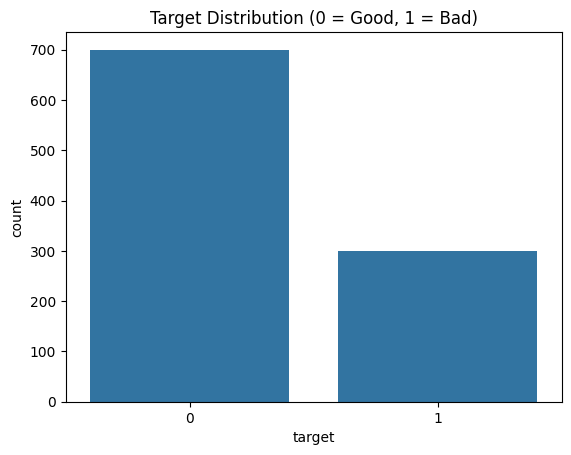

In [9]:
# Target Distribution
sns.countplot(x='target', data=df)
plt.title("Target Distribution (0 = Good, 1 = Bad)")
plt.show()

- Approximately 70% of borrowers are classified as good credit risks, while 30% are classified as bad.
- This indicates moderate class imbalance.

##**Visualizing Key Relationships**

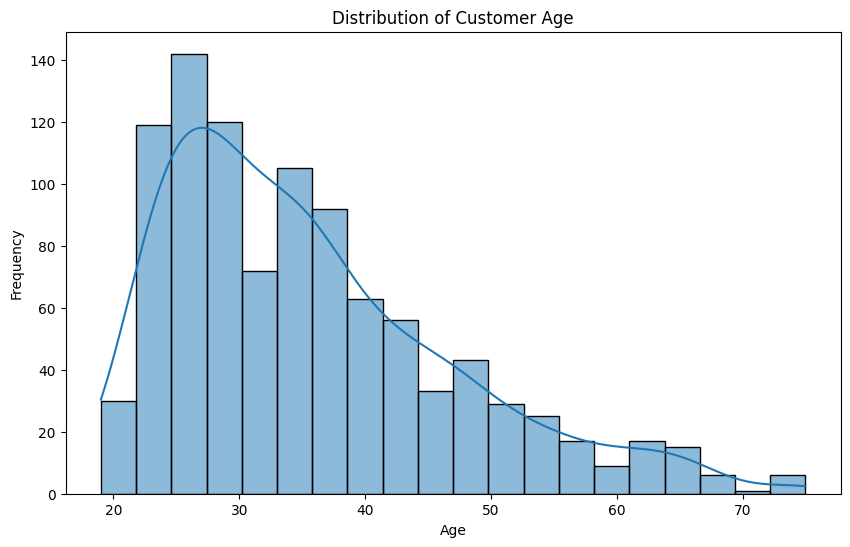

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, bins=20)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The histogram displays the distribution of customer age. The plot indicates that the majority of customers are concentrated in the younger to middle-aged adult categories, with a peak around 25-35 years old, and fewer customers in the older age groups. The distribution appears right-skewed.



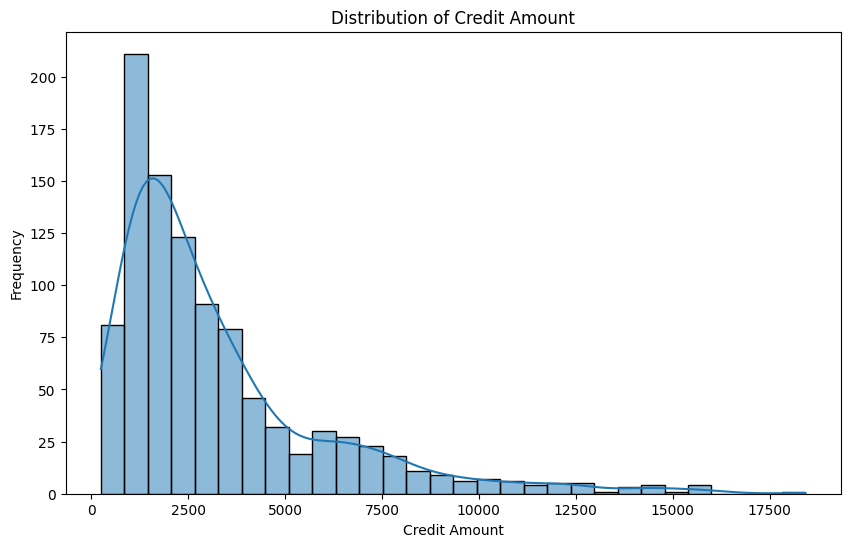

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['credit_amount'], kde=True, bins=30)
plt.title('Distribution of Credit Amount')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution of credit amounts. It appears to be right-skewed, meaning that most credit amounts are lower, with fewer instances of very high credit amounts.



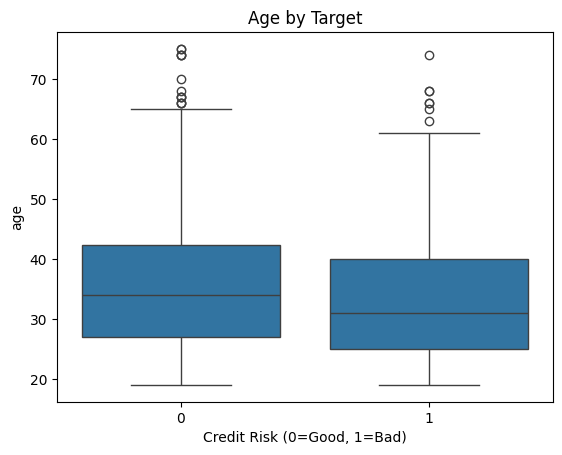

In [12]:
# Age vs Target
sns.boxplot(x='target', y='age', data=df)
plt.title("Age by Target")
plt.xlabel('Credit Risk (0=Good, 1=Bad)')
plt.show()

### Interpretation of Age vs. Target

- The median age of good credit borrowers appears slightly higher than that of bad credit borrowers. This suggests that younger borrowers may have a somewhat higher probability of default compared to older borrowers.

- However, there is substantial overlap between the age distributions of the two groups. This indicates that age alone is not a strong predictor of credit default, although it may contribute to risk assessment when combined with other variables in a multivariate model.

- Overall, age shows a mild relationship with credit risk, but it does not clearly separate good and bad borrowers.

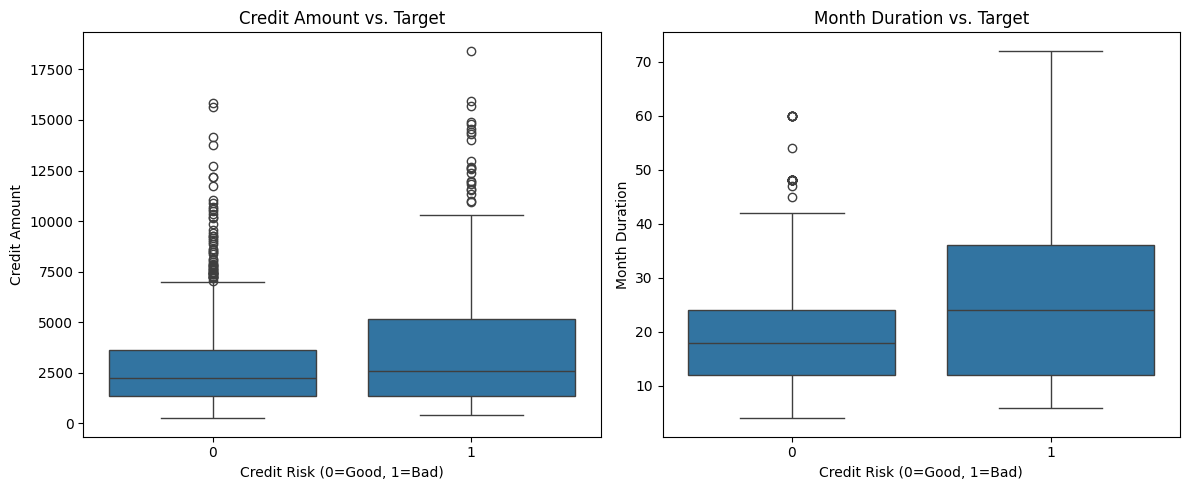

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(data=df, x='target', y='credit_amount')
plt.title('Credit Amount vs. Target')
plt.xlabel('Credit Risk (0=Good, 1=Bad)')
plt.ylabel('Credit Amount')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(data=df, x='target', y='month_duration')
plt.title('Month Duration vs. Target')
plt.xlabel('Credit Risk (0=Good, 1=Bad)')
plt.ylabel('Month Duration')

plt.tight_layout()
plt.show()

### **Interpretation of Key Relationships**

The boxplots above compare the distribution of **credit amount** and **loan duration** across the two target classes:

- 0 = Good credit risk  
- 1 = Bad credit risk  

#### **Credit Amount vs. Target**

- The median `credit amount` for borrowers classified as **bad credit risks (1)** appears slightly higher than that of **good credit risks (0)**.
- Additionally, the bad credit group shows greater variability and more extreme high-value outliers.

- This suggests that larger loan amounts may be associated with a higher probability of default. However, there is substantial overlap between the two distributions, indicating that credit amount alone is not a strong standalone predictor of default risk.

#### **Loan Duration vs. Target**

- The median `loan duration` is clearly higher for **bad credit risks (1)** compared to **good credit risks (0)**. Borrowers who default tend to have longer repayment periods.

- This indicates a potential positive relationship between **loan duration** and **default probability**. Longer loan commitments may increase financial strain or uncertainty, thereby increasing default risk.

#### **Overall Interpretation**

While both `credit amount` and `loan duration` show differences between the two classes, the overlap in distributions suggests that no single variable perfectly separates **good** and **bad** credit risks. This justifies the need for multivariate modeling techniques, such as logistic regression combined with dimensionality reduction (PCA), to capture the combined effects of multiple predictors.

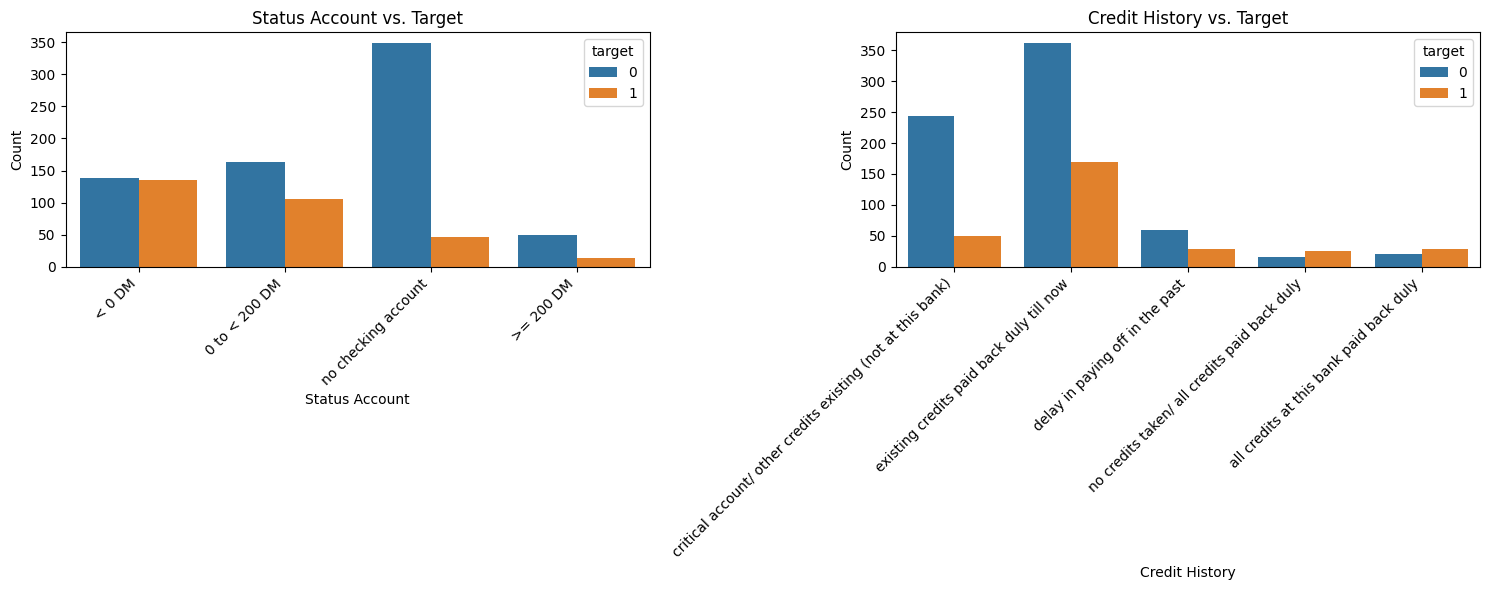

In [14]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='status_account', hue='target')
plt.title('Status Account vs. Target')
plt.xlabel('Status Account')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='credit_history', hue='target')
plt.title('Credit History vs. Target')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### **Status of Checking Account vs. Target**

This chart illustrates that the amount of money held in a checking account is a strong indicator of credit risk.

#### **High Risk ($< 0$ DM)**

- Borrowers with an overdrawn or negative checking account balance show an almost $1:1$ ratio of bad credit risks (Target $=1$) to good credit risks (Target $=0$).  
- This category represents the highest observed risk level.

#### **Low Risk (No Checking Account)**

- Interestingly, individuals recorded as having no checking account exhibit the highest count of good credit risks and a relatively low proportion of bad risks.  
- This may indicate alternative financial stability mechanisms or conservative borrowing behavior.

#### **General Trend**

- As the account balance increases (from negative balances to $\geq 200$ DM), the relative proportion of bad credit risks decreases.  
- This suggests a negative relationship between checking account balance and default probability.

---

### **Credit History vs. Target**

This chart examines how past credit behavior relates to current default risk.

#### **The "Critical" Paradox**

- Borrowers categorized as having a "critical account/other credits existing" show a substantially higher number of good credit risks compared to bad ones.  
- This may indicate that the term "critical" refers to complex but actively managed credit arrangements, rather than poor repayment behavior.

#### **"Existing Credits Paid Duly" Group**

- The largest borrower group consists of individuals whose existing credits have been paid back duly until now.  
- Although this category contains the highest number of good credit risks, it also includes a significant number of bad risks, likely due to its broad and heterogeneous nature.

#### **Potential Warning Signs**

- Categories such as **"all credits at this bank paid back duly"** and **"no credits taken"** display a relatively higher proportion of bad credit risk compared to their total volume when contrasted with the "critical" group.  
- This suggests that limited or overly simplistic credit history may not necessarily indicate lower default risk.

---

Overall, `credit history` and `checking account` status appear to be meaningful predictors of credit default and should contribute significantly in multivariate modeling.

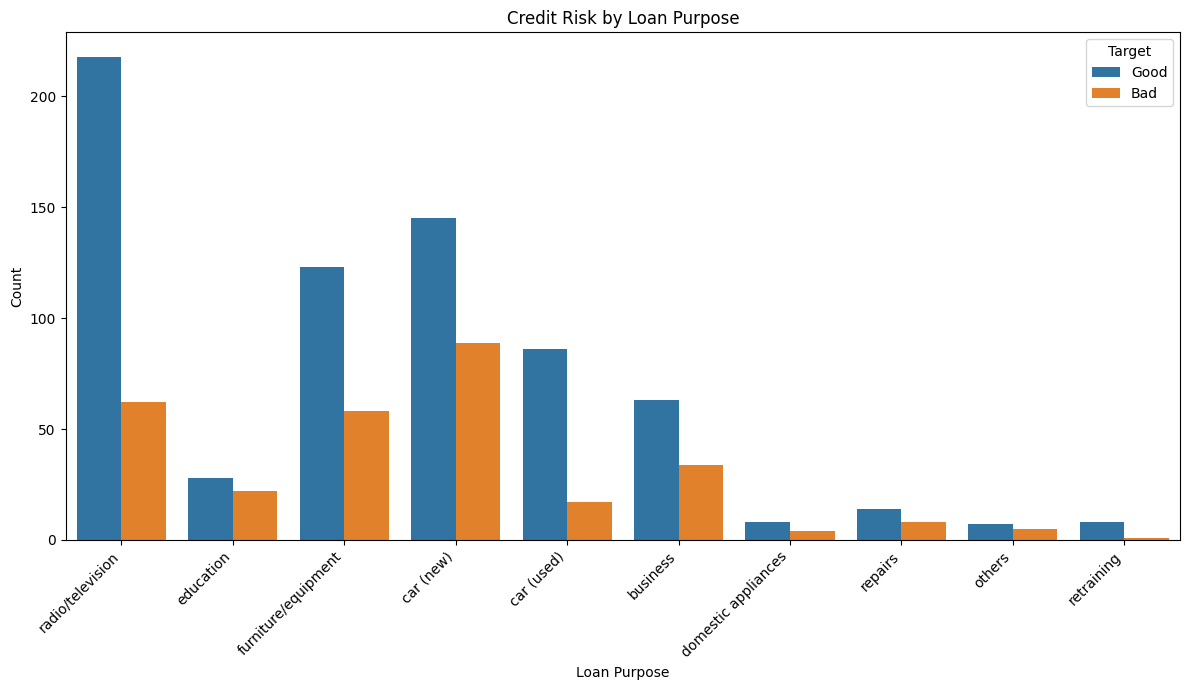

In [15]:
plt.figure(figsize=(12, 7))
sns.countplot(x='purpose', hue='target', data=df)
plt.title('Credit Risk by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Target', labels=['Good', 'Bad'])
plt.tight_layout()
plt.show()

This plot shows the number of 'good' and 'bad' credit risks for each category of loan purpose.

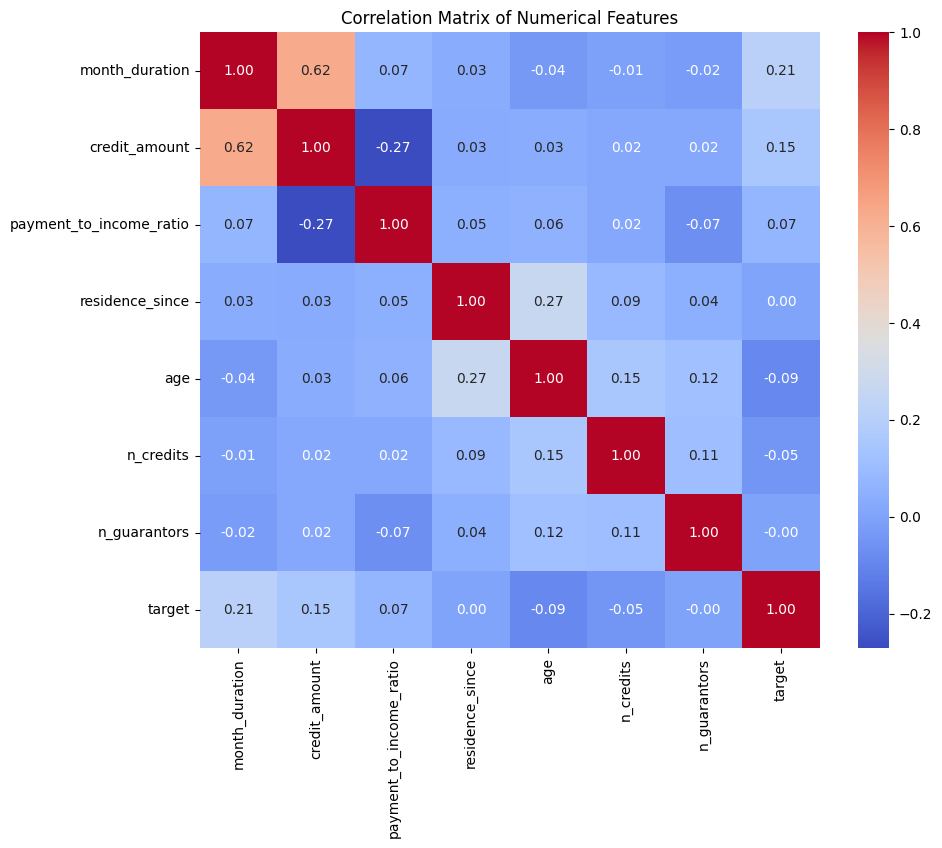

In [16]:
# Calculate the correlation matrix for all numerical features
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### **Correlation Matrix Interpretation:**
1.  **`month_duration` and `credit_amount` (Correlation: 0.62):** There is a moderately strong positive correlation between `month_duration` and `credit_amount`. This suggests that loans with longer durations tend to have higher credit amounts.

2. **`credit_amount` and `payment_to_income_ratio` (Correlation: -0.27):**
There is a weak negative correlation between `credit_amount` and `payment_to_income_ratio`. This means that as credit amount increases, the payment to income ratio tends to slightly decrease.
- This could reflect that larger loans are given to individuals with higher incomes, thus keeping the ratio somewhat in check, or that riskier large loans are offset by stricter income requirements.

3. **`month_duration` and `payment_to_income_ratio`(Correlation: 0.07):** There is a very weak positive correlation, suggesting almost no linear relationship between loan duration and payment-to-income ratio.

4. **Other Correlations:** Most other numerical features `residence_since` , `age` , `n_credits` , `n_guarantors` show very weak positive or negative correlations with each other and with `month_duration` , `credit_amount` , and `payment_to_income_ratio`.
- This indicates that these variables are largely independent of each other in a linear sense.



## **Test for Normality**
Performing normality tests using P-P plots, Q-Q plots, and the Shapiro-Wilk test for relevant numerical features. This will help assess if the data follows a normal distribution.



--- Normality Test for: credit_amount ---


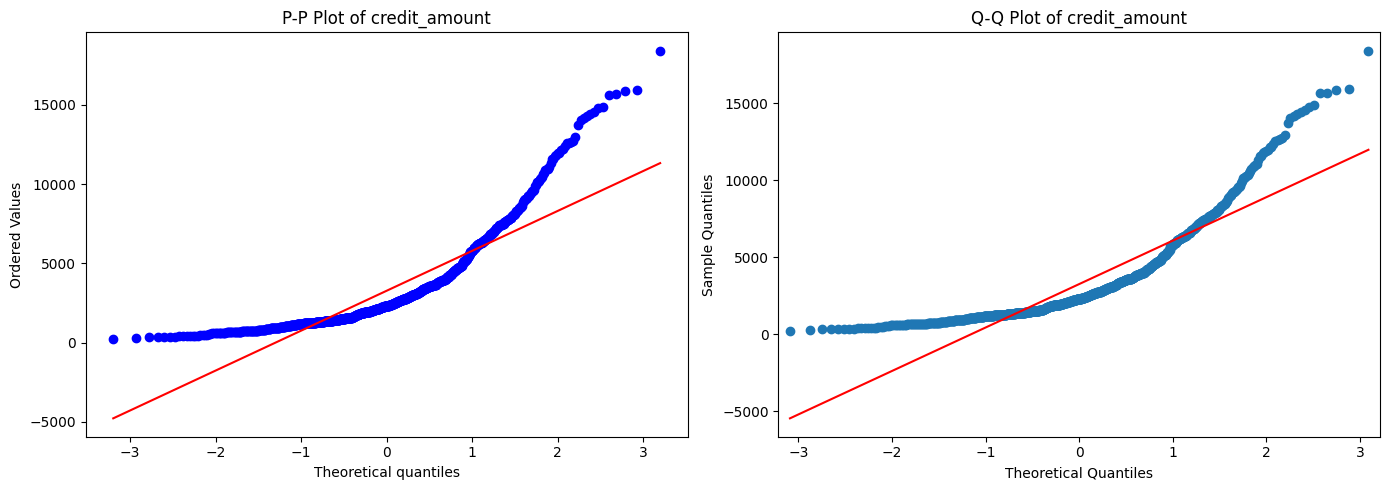

Shapiro-Wilk Test Statistic for credit_amount: 0.7934
Shapiro-Wilk P-value for credit_amount: 0.0000
Conclusion: credit_amount is likely not normally distributed (p < 0.05)

--- Normality Test for: month_duration ---


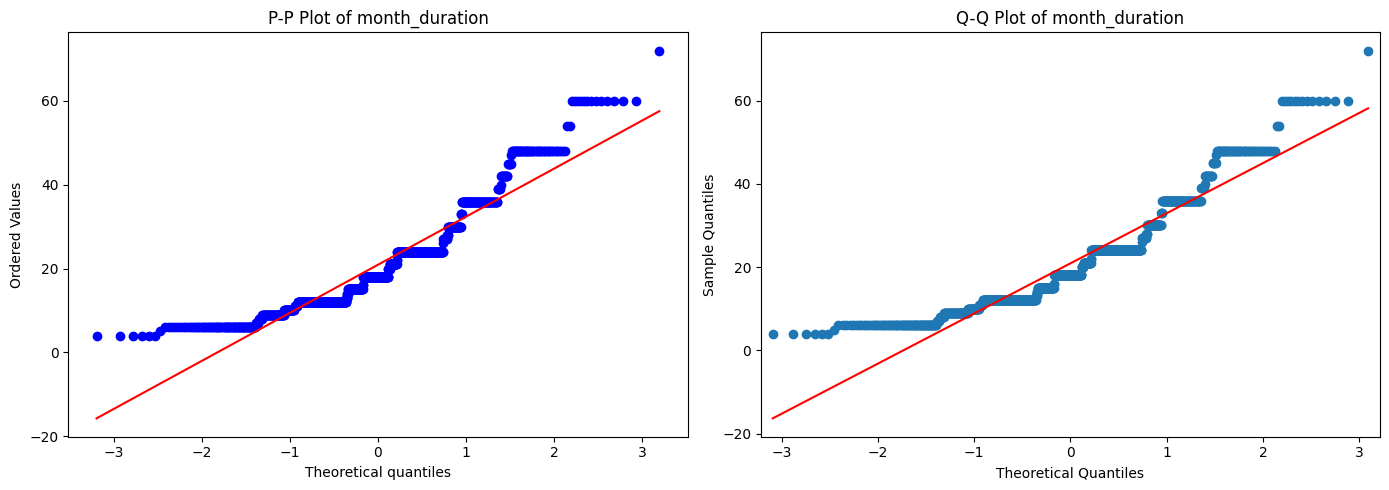

Shapiro-Wilk Test Statistic for month_duration: 0.8998
Shapiro-Wilk P-value for month_duration: 0.0000
Conclusion: month_duration is likely not normally distributed (p < 0.05)

--- Normality Test for: age ---


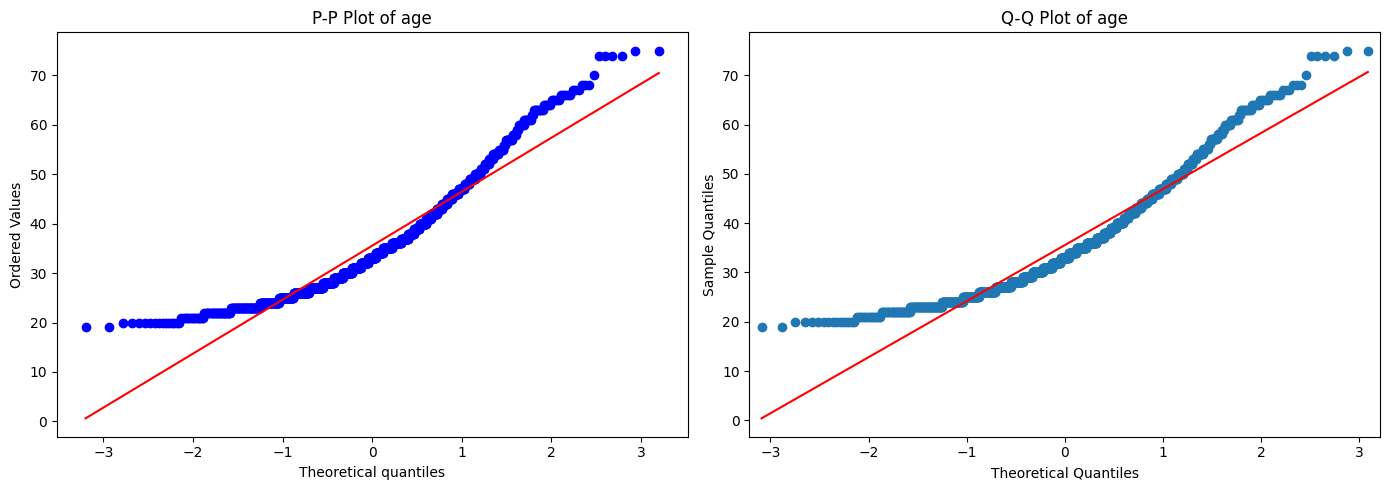

Shapiro-Wilk Test Statistic for age: 0.9175
Shapiro-Wilk P-value for age: 0.0000
Conclusion: age is likely not normally distributed (p < 0.05)


In [17]:
from scipy import stats
import statsmodels.api as sm

# Numerical columns to test for normality
numerical_cols = ['credit_amount', 'month_duration', 'age']

for feature in numerical_cols:
    print(f"\n--- Normality Test for: {feature} ---")

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # P-P Plot
    stats.probplot(df[feature], dist="norm", plot=axes[0])
    axes[0].set_title(f'P-P Plot of {feature}')

    # Q-Q Plot
    sm.qqplot(df[feature], line='s', ax=axes[1])
    axes[1].set_title(f'Q-Q Plot of {feature}')

    plt.tight_layout()
    plt.show()

    # Shapiro-Wilk Test
    shapiro_statistic, shapiro_pvalue = stats.shapiro(df[feature])
    print(f"Shapiro-Wilk Test Statistic for {feature}: {shapiro_statistic:.4f}")
    print(f"Shapiro-Wilk P-value for {feature}: {shapiro_pvalue:.4f}")
    if shapiro_pvalue < 0.05:
        print(f"Conclusion: {feature} is likely not normally distributed (p < 0.05)")
    else:
        print(f"Conclusion: {feature} might be normally distributed (p >= 0.05)")

In [18]:
print("### Shapiro-Wilk Test for Normality")

for col in numerical_cols:
    stat, p = stats.shapiro(df[col])
    print(f'\nShapiro-Wilk Test for {col}:')
    print(f'Statistic = {stat:.3f}, p = {p:.3f}')
    if p > 0.05:
        print(f'Sample looks Gaussian (fail to reject H0 for {col})')
    else:
        print(f'Sample does not look Gaussian (reject H0 for {col})')

### Shapiro-Wilk Test for Normality

Shapiro-Wilk Test for credit_amount:
Statistic = 0.793, p = 0.000
Sample does not look Gaussian (reject H0 for credit_amount)

Shapiro-Wilk Test for month_duration:
Statistic = 0.900, p = 0.000
Sample does not look Gaussian (reject H0 for month_duration)

Shapiro-Wilk Test for age:
Statistic = 0.917, p = 0.000
Sample does not look Gaussian (reject H0 for age)


###**Interpretation of Shapiro-wilks, Q-Q and P-P plots**
#### **Shapiro-wilks test for normality:**
- **H0**: null hypothesis that data is drawn from a normal distribution.
- **H1**: alternative hypothesis that data is not drawn from a normal distribution.
- A **p-value greater than 0.05:** we fail to reject the nulll hypothesis, suggesting that the data is normally distributed.
- **A p-value less than or equal to 0.05:** we reject the null hypothesis (H0) suggesting that the data is not normally distributed.
- As observed from the results, **p-values** for `credit_amount` `month_duration` `age` are all **zero** (p-value<=0.05), hence we reject the nyll hypothesis suggesting that these numerical columns do not appear to be normally distributed.

### **Q-Q and P-P plots**
 - These plots visually assess if `credit_amount` `month_duration` `age` data follows a normal distribution.
 - If the data points closely align with the red line, it suggests normality. Deviations from the line indicate departures from normality.
 - From the plots, it appears that  `credit_amount` `month_duration` `age` are not normally distributed, as most points deviate from the straight line, especially at the tails.

### **Identify Categorical Features**
Identify all categorical columns (object dtype) in the DataFrame that need to be encoded, excluding the already processed 'target' column.


In [19]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'target' in categorical_cols:
    categorical_cols.remove('target')
print(f"Categorical columns to encode: {categorical_cols}")

Categorical columns to encode: ['status_account', 'credit_history', 'purpose', 'status_savings', 'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral', 'other_installment_plans', 'housing', 'job', 'telephone', 'is_foreign_worker']


### **One-Hot Encoding Categorical Features**
Perform one-hot encoding on all identified categorical columns (`categorical_cols`).
1. Use `pd.get_dummies` to one-hot encode the
categorical columns in the DataFrame `df`.
2. Concatenate the new one-hot encoded columns with the original DataFrame and drop the original categorical columns.
3. Store the result in the `df` variable.

In [20]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

In [21]:
print("DataFrame after one-hot encoding:")
df.head()

DataFrame after one-hot encoding:


,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,target,status_account_0 to < 200 DM,status_account_< 0 DM,...,housing_own,housing_rent,job_management/ self-employed/highly qualified employee,job_skilled employee/ official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",is_foreign_worker_no,is_foreign_worker_yes
0,6,1169,4,4,67,2,1,0,False,True,...,True,False,False,True,False,False,False,True,False,True
1,48,5951,2,2,22,1,1,1,True,False,...,True,False,False,True,False,False,True,False,False,True
2,12,2096,2,3,49,1,2,0,False,False,...,True,False,False,False,False,True,True,False,False,True
3,42,7882,2,4,45,1,2,0,False,True,...,False,False,False,True,False,False,True,False,False,True
4,24,4870,3,4,53,2,2,1,False,True,...,False,False,False,True,False,False,True,False,False,True


### **Log Transformation of Skewed Numerical Features**
To address the non-normal distributions of transform the `credit_amount`, `month_duration`, and `age` columns.
1. Apply `np.log1p` to the `credit_amount`, `month_duration`, and `age` columns in the DataFrame `df`.
2. Overwrite the original columns with their log-transformed values.

In [22]:
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [23]:
df['credit_amount'] = np.log1p(df['credit_amount'])
df['month_duration'] = np.log1p(df['month_duration'])
df['age'] = np.log1p(df['age'])

In [24]:
print("DataFrame after log transformation of skewed numerical features:")
print(df[['credit_amount', 'month_duration', 'age']].head())

DataFrame after log transformation of skewed numerical features:
   credit_amount  month_duration       age
0       7.064759        1.945910  4.219508
1       8.691483        3.891820  3.135494
2       7.648263        2.564949  3.912023
3       8.972464        3.761200  3.828641
4       8.491055        3.218876  3.988984


In [25]:
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.940942,7.789244,2.973000,2.845000,3.554569,1.407000,1.155000,0.300000
std,0.546377,0.776074,1.118715,1.103718,0.291418,0.577654,0.362086,0.458487
min,1.609438,5.525453,1.000000,1.000000,2.995732,1.000000,1.000000,0.000000
25%,2.564949,7.220008,2.000000,2.000000,3.332205,1.000000,1.000000,0.000000
50%,2.944439,7.749538,3.000000,3.000000,3.526361,1.000000,1.000000,0.000000
75%,3.218876,8.287340,4.000000,4.000000,3.761200,2.000000,1.000000,1.000000
max,4.290459,9.821464,4.000000,4.000000,4.330733,4.000000,2.000000,1.000000


### **Scaling Numerical Features**

Scale all numerical features in the DataFrame `df` using `StandardScaler`.
1. Import `StandardScaler` from `sklearn.preprocessing`.
2. Identify all numerical columns in the DataFrame `df` that are not the 'target' column.
3. Initialize `StandardScaler`.
4. Fit and transform the identified numerical columns using the scaler.
5. Replace the original numerical columns in `df` with their scaled versions.

In [26]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (non-boolean, non-target)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'target' in numerical_cols:
    numerical_cols.remove('target')

# Remove boolean columns if any were included as numbers (from get_dummies)
# `df.select_dtypes(include=np.number)` can sometimes include booleans as numbers
numerical_cols = [col for col in numerical_cols if df[col].dtype != 'bool']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [27]:
print("DataFrame after scaling numerical features:")
df[numerical_cols].head()

DataFrame after scaling numerical features:


,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
0,-1.822056,-0.933992,0.918477,1.046987,2.282879,1.027079,-0.428290
1,1.741206,1.163149,-0.870183,-0.765977,-1.438777,-0.704926,-0.428290
2,-0.688500,-0.181750,-0.870183,0.140505,1.227217,-0.704926,2.334869
3,1.502020,1.525385,-0.870183,1.046987,0.940950,-0.704926,2.334869
4,0.508940,0.904761,0.024147,1.046987,1.491441,1.027079,2.334869


### **Data Modeling Preparation**
Separate the features (X) from the target variable (y) in the preprocessed DataFrame.


In [28]:
X = df.drop('target', axis=1)
y = df['target']

In [29]:
# Split the features (X) and target (y) into training and testing sets using `train_test_split`.
# This is crucial for evaluating the model's performance on unseen data.

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (800, 61)
Shape of X_test: (200, 61)
Shape of y_train: (800,)
Shape of y_test: (200,)


### **Apply Principal Component Analysis (PCA)**
- Apply PCA to the training data (X_train) to reduce dimensionality.
- Determine an appropriate number of components to retain a significant portion of the variance (e.g., 95%) or choose a fixed number of components. Then transform both the training and test sets.


In [30]:
from sklearn.decomposition import PCA

# Initialize PCA without specifying n_components to analyze explained variance
pca = PCA(n_components=None)
print("PCA initialized for explained variance analysis.")

PCA initialized for explained variance analysis.


**Analyzing explained variance**:
Fit the PCA model to the training data (`X_train`) and then plot the cumulative explained variance ratio to visualize how many components are needed to retain a significant portion of the variance.



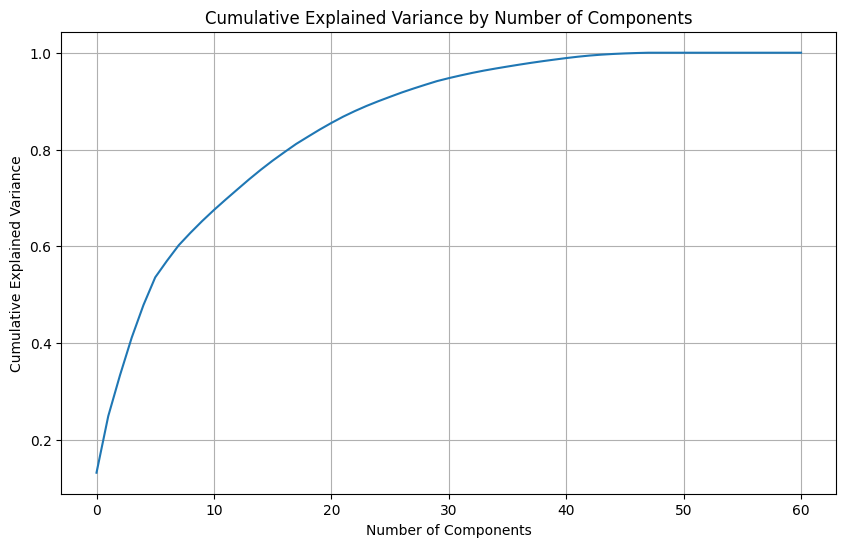

Explained variance ratio computed and plotted.


In [31]:
pca.fit(X_train)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Number of Components')
plt.grid(True)
plt.show()

print("Explained variance ratio computed and plotted.")

Based on the cumulative explained variance plot,  re-initialize PCA with `n_components=0.95` to retain 95% of the variance, and then fit and transform both the training and test sets to reduce their dimensionality.



In [32]:
pca = PCA(n_components=0.95)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Transformed X_train_pca shape: {X_train_pca.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Transformed X_test_pca shape: {X_test_pca.shape}")
print(f"Number of components selected: {pca.n_components_}")

Original X_train shape: (800, 61)
Transformed X_train_pca shape: (800, 32)
Original X_test shape: (200, 61)
Transformed X_test_pca shape: (200, 32)
Number of components selected: 32


**Dimensionality reduction summary:**
- **Principal Component Analysis (PCA)** was applied to the training data.
- Initially, the PCA was fitted to determine the explained variance ratio, which helped in deciding the number of components.
- Subsequently, PCA was re-initialized to retain 95% of the variance, resulting in a reduction from 61 original features to 32 principal components.
- Both the training and test sets were then transformed using this PCA model.

### **Train Supervised Classification Model**

Using Logistic Regression, initialize it, and train it using the PCA-transformed training data (X_train_pca) and the corresponding training target (y_train).

 `random_state=42` for reproducibility, and then fit it to the PCA-transformed training data and the training target


In [33]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using PCA-transformed training data
model.fit(X_train_pca, y_train)

print("Logistic Regression model trained successfully on PCA-transformed data.")

Logistic Regression model trained successfully on PCA-transformed data.


### **Evaluate Model Performance**
- Make predictions on the PCA-transformed test data (X_test_pca) and evaluate the model's performance using accuracy as the metric.
- Print the test accuracy.


In [34]:
from sklearn.metrics import accuracy_score

# Make predictions on the PCA-transformed test data
y_pred = model.predict(X_test_pca)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7700


### **Compute Confusion Matrix**
Calculating the following metrics: precision, recall, and F1-score.

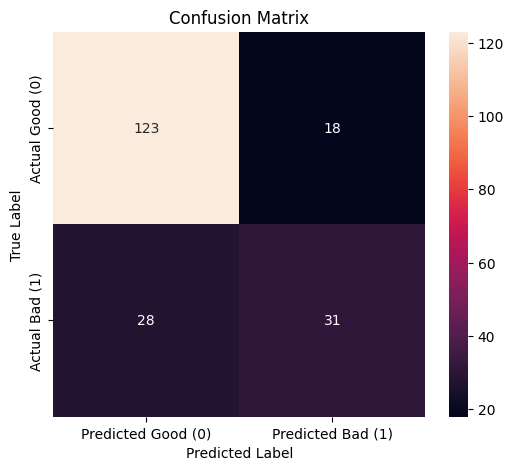


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       141
           1       0.63      0.53      0.57        59

    accuracy                           0.77       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200



In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
            yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### **Interpretation of Confusion Matrix**
[
\begin{array}{c|cc}
 & \text{Predicted Good (0)} & \text{Predicted Bad (1)} \\
\hline
\text{Actual Good (0)} & 123 & 18 \\
\text{Actual Bad (1)} & 28 & 31 \\
\end{array}
]

From this matrix:

- **True Positives (TP)** = 31  
- **True Negatives (TN)** = 123  
- **False Positives (FP)** = 18  
- **False Negatives (FN)** = 28  

#### Interpretation:

*   **True Positives (TP)**: The number of 'bad' credit risks correctly identified by the model.
*   **True Negatives (TN)**: The number of 'good' credit risks correctly identified by the model.
*   **False Positives (FP)**: The number of 'good' credit risks incorrectly classified as 'bad' (Type I error).
*   **False Negatives (FN)**: The number of 'bad' credit risks incorrectly classified as 'good' (Type II error).
---

- **True Negatives (TN):** The model correctly classified **123 good borrowers**.
- **True Positives (TP):** The model correctly identified **31 bad borrowers (defaulters)**.
- **False Positives (FP):** The model incorrectly rejected **18 good borrowers** (Type I error).
- **False Negatives (FN):** The model failed to identify **28 bad borrowers**(Type II error).

In a credit risk context, false negatives (approving a bad borrower) are typically more costly than false positives (rejecting a good borrower).

---

### **Interpretation of Classification Metrics**
- The model achieved an **accuracy of 77%**. This means it correctly classifies 77% of all test observations.  
While reasonably high, accuracy alone may be misleading due to class imbalance (70\% good vs 30\% bad).


#### **Class 0 (Good Credit Risk)**

- **Precision = 0.81**  
  Of all borrowers predicted as good, 81\% were actually good.

- **Recall = 0.87**  
  The model correctly identified 87\% of all actual good borrowers.

- **F1-score = 0.84**  
  Indicates strong overall performance for the good credit class.


#### **Class 1 (Bad Credit Risk)**

- **Precision = 0.63**  
  Of all borrowers predicted as bad, 63\% were actually bad.

- **Recall = 0.53**  
  The model correctly identified only 53\% of actual defaulters.

- **F1-score = 0.57**  
  Performance for detecting bad credit risks is moderate and significantly lower than for good borrowers.

---

### **Most Important Metric in Diagnosis Scenario**

In a credit risk diagnosis scenario, especially when identifying 'bad' credit risks (class 1), **Recall** for the 'bad' class is often the most important metric.

*   **Cost of False Negatives**: A False Negative (Type II error) occurs when the model incorrectly classifies a `bad` credit risk as `good`. This has severe financial implications for the bank, as it could lead to significant loan defaults and losses. The cost of lending money to a high-risk individual who defaults is typically much higher than the cost of mistakenly denying a loan to a low-risk individual.
*   **Minimizing Risk**: The primary goal in credit risk assessment is to minimize the bank's exposure to risky loans. Maximizing **Recall** for the `bad` class ensures that as many actual `bad` credit risks as possible are caught, even if it means a slight increase in False Positives (denying a few `good` applicants). The bank would rather be safe than sorry.

While precision is also important (to avoid denying too many 'good' customers), recall is often prioritized to mitigate substantial financial losses.


#### **Plotting ROC Curve and AUC**

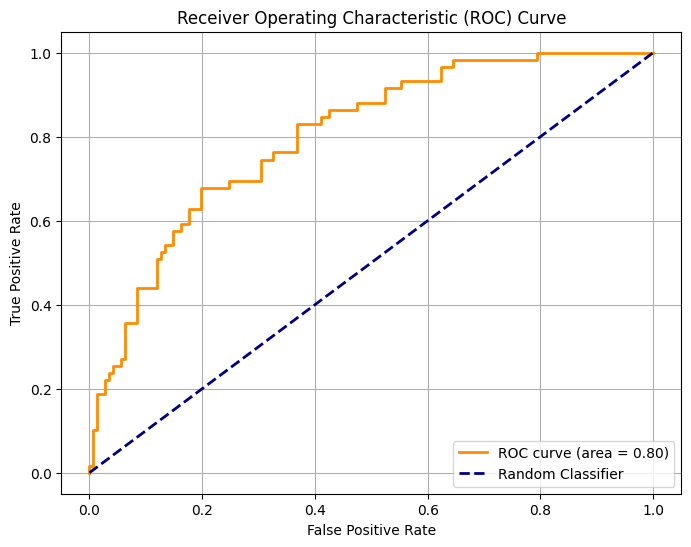

In [36]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = model.predict_proba(X_test_pca)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **ROC Curve and Model Performance Evaluation**

The Receiver Operating Characteristic (ROC) curve evaluates the discriminatory ability of the classification model by plotting the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** across varying decision thresholds.

---

Area Under the Curve (AUC) = 0.80

- An AUC value of $0.80$ indicates **good discriminatory performance**.  
- Specifically, there is an 80\% probability that the model will assign a higher risk score to a randomly selected borrower who defaults (Bad credit risk) than to a randomly selected borrower who does not default (Good credit risk).

- For comparison, a non-informative classifier would yield (AUC) = 0.50

Thus, the proposed model demonstrates substantial improvement over random classification.

---

### **Threshold Trade-offs**

The ROC curve illustrates the inherent trade-off between sensitivity and specificity:

- The initial steep slope indicates that the model achieves relatively high sensitivity with only a small increase in false positives.
- However, beyond a recall (TPR) level of approximately $0.80$, the False Positive Rate increases more rapidly.
  
This implies that aggressively minimizing false negatives (i.e., attempting to capture nearly all high-risk borrowers) will result in a higher proportion of low-risk borrowers being incorrectly classified as high-risk.

Such trade-offs should be evaluated in light of institutional risk tolerance and cost considerations.

---

### **Contextualizing with Confusion Matrix**

While the ROC curve reflects performance across all thresholds, the confusion matrix evaluates model performance at a specific operating point.

| **Classification Outcome** | **Count** | **Interpretation** |
|----------------------------|-----------|--------------------|
| True Negatives (TN)        | 123       | Correctly classified low-risk (Good) borrowers. |
| True Positives (TP)        | 31        | Correctly identified high-risk (Bad) borrowers. |
| False Negatives (FN)       | 28        | High-risk borrowers incorrectly classified as low-risk; represents potential credit loss exposure. |
| False Positives (FP)       | 18        | Low-risk borrowers incorrectly classified as high-risk; may lead to lost business opportunities. |

---

#### **Overall Assessment**

The model achieves a reasonable balance between sensitivity and specificity, with an overall accuracy of approximately $77\%$.  

However, the relatively lower recall for the minority class (Bad credit risk) suggests that further threshold tuning or class-balancing techniques may be considered to improve high-risk detection, depending on the financial institution’s strategic objectives.

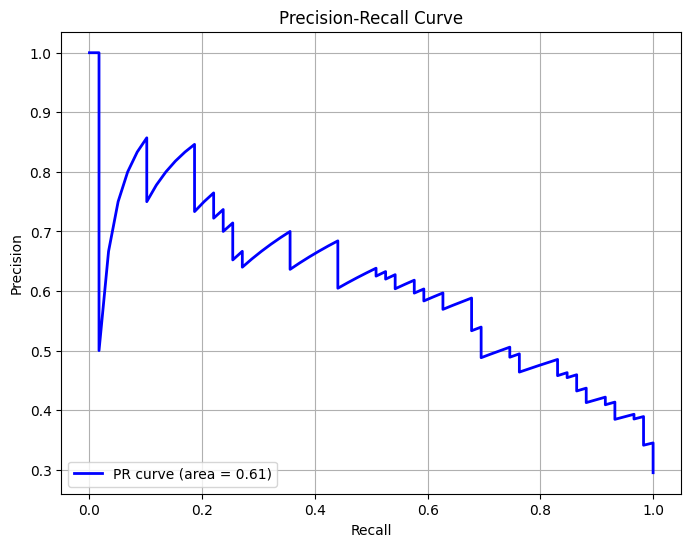

In [37]:
# Precision-Recall curve for class imbalances
from sklearn.metrics import precision_recall_curve, auc

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = model.predict_proba(X_test_pca)[:, 1]

# Calculate Precision-Recall curve metrics
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### **Precision--Recall (PR) Curve Analysis**

The Precision--Recall (PR) curve evaluates model performance on the minority class
(**Target 1: Bad Credit Risk**) by examining the trade-off between:

\begin{align*}
\text{Precision} &= \frac{TP}{TP + FP} \\
\text{Recall} &= \frac{TP}{TP + FN}
\end{align*}


This metric is particularly informative under class imbalance.

---

### **Area Under the Curve (AUC / Average Precision)**

(AUC--PR) = 0.61

- The Average Precision (AP) of $0.61$ indicates moderate effectiveness in identifying bad credit risks.

- Although the ROC curve produced a relatively strong value (AUC--ROC) = $0.80$

- The lower PR value reveals that the model performs less strongly when evaluated specifically on the minority (*Bad*) class.

Importantly, because bad credit risks represent:

$$\frac{59}{200} = 0.295 \quad (29.5\%)$$


a no-skill classifier would yield a horizontal baseline at $0.295$.

Since $0.61 \gg 0.295$, the model is clearly learning meaningful predictive patterns.

---

### **Precision--Recall Trade-off**

As recall increases, precision decreases.

To achieve:

$$\text{Recall} \approx 0.80$$

precision falls toward approximately $0.50$.

- This implies that to capture 80\% of actual defaulters, roughly half of the borrowers flagged as `Bad` would actually be creditworthy customers.

Thus, increasing detection of defaulters comes at the cost of rejecting more good applicants.

---

### **ROC vs PR Curve Comparison**

| Metric | ROC Curve | PR Curve |
|--------|------------|------------|
| Area Value | 0.80 | 0.61 |
| Perspective | Evaluates both classes equally | Focuses on minority class |
| Interpretation Bias | More optimistic under imbalance | More realistic for rare events |
| Best Use | General model comparison | Business risk evaluation |

---

### **Strategic Implications**

The jagged shape of the PR curve suggests sensitivity in predicted probabilities.  
Small adjustments to the classification threshold may result in substantial shifts in:

- The number of defaulters correctly identified, and  
- The number of good customers incorrectly rejected.

From a business perspective, threshold selection should be guided by:

- The financial cost of false negatives (missed defaulters),  
- The opportunity cost of false positives (lost customers), and  
- The institution’s overall risk tolerance.

Overall, while the model demonstrates meaningful discriminatory capability, further refinement may improve its precision--recall balance for high-risk borrower detection.

### **Actionable Recommendations**

##### A. **Improving Detection of High-Risk Borrowers**

To enhance identification of bad credit risks (Target = 1), the following steps are recommended:

**1. Adjust the Classification Threshold**
- Lower the decision threshold below 0.50.
- This increases recall (captures more defaulters).
- Evaluate impact using the Precision–Recall curve.

**2. Apply Class Imbalance Techniques**
- Use class weighting (e.g., `class_weight='balanced'`).
- Implement resampling methods:
  - Oversampling (e.g., SMOTE)
  - Undersampling majority class
- Compare performance using AUC-PR and recall.

**3. Optimize for Recall or Cost-Based Metrics**
- Instead of optimizing accuracy, tune the model for:
  $$\text{Recall} = \frac{TP}{TP + FN}$$

- Alternatively, use a cost-sensitive objective function where False Negatives carry higher penalties.

**4. Feature Engineering**
- Create interaction variables (e.g., credit history × account balance).
- Transform skewed financial variables.
- Remove weak predictors based on feature importance.

**5. Model Comparison**
- Compare multiple models (e.g., Logistic Regression, Random Forest, Gradient Boosting).
- Select model based on minority-class performance (AUC-PR).

---

##### B. **Aligning Predictive Performance with Financial Decision-Making**

Model evaluation should reflect business impact, not just statistical metrics.

**1. Quantify Financial Cost of Errors**

Assign estimated monetary values:

- False Negative (FN): Cost of loan default  
- False Positive (FP): Lost interest revenue + customer opportunity cost  

Then compute expected cost:

$$\text{Total Cost} = (FN \times Cost_{FN}) + (FP \times Cost_{FP})$$


Select the threshold that minimizes total expected cost.



**2. Define Risk Tolerance Policy**

- Conservative strategy → Prioritize high recall (minimize defaults).
- Growth strategy → Prioritize precision (avoid rejecting good customers).

Threshold choice should reflect institutional risk appetite.


**3. Segment-Based Decision Strategy**

Instead of binary approve/decline:
- Low risk → Approve automatically
- Medium risk → Manual review
- High risk → Reject or require collateral

This reduces both financial risk and customer dissatisfaction.


**4. Continuous Monitoring**

- Track model drift over time.
- Re-evaluate AUC-PR and recall quarterly.
- Retrain model when performance degrades.
---

### **Summary**

Improving high-risk detection requires:
- Threshold tuning,
- Handling class imbalance,
- Cost-sensitive optimization.

Aligning performance with financial decisions requires:
- Explicit cost modeling,
- Strategic threshold selection,
- Risk-based segmentation.

### **Followup Recommendations**

Model performance should be improved with a dual objective:
- Increase detection of high-risk borrowers  
- Align model decisions with financial impact  


### **A. Improving Detection of High-Risk Borrowers**

The current Recall for Class 1 (Bad Credit Risk) is:

$$\text{Recall}_{Bad} = 0.53$$

This means the model fails to detect:

$$\frac{28}{59} \text{ (28 out of 59 instances)}$$


actual defaulters — nearly half.

#### **1. Adjust the Classification Threshold**

The ROC curve shows:
$$\text{AUC--ROC} = 0.80$$
indicating strong class separability.  
However, the **default threshold of 0.50** is too conservative.

**Action:**  
Lower the threshold to approximately `0.35`

Expected impact:
- Increase True Positives (reduce False Negatives)
- Improve recall substantially
- Accept moderate increase in False Positives

This is the fastest way to reduce lending to high-risk borrowers.


#### **2. Address Class Imbalance**

Since Bad risks represent:

$$\frac{59}{200} = 29.5\%$$

the model is biased toward predicting the majority class.

**Actions:**
- Apply class weighting (approximately $1:2.4$ ratio)
- Use SMOTE oversampling during training
- Optimize for AUC--PR instead of accuracy


#### **3. Optimize Using the PR Curve**

The Precision--Recall curve shows:
$$\text{AUC--PR} = 0.61$$

Precision declines toward $0.50$ when recall approaches $0.80$.

**Recommendation:**  
Select threshold using a Max-F1 or cost-sensitive optimization strategy to balance:
- Capturing defaulters
- Avoiding excessive rejection of good customers

---

### **B. Aligning Predictive Performance with Financial Decision-Making**

Accuracy alone is not sufficient in credit risk modeling.

#### **1. Use Cost-Sensitive Optimization (Highest Financial Impact)**

- In banking, False Negatives are significantly more expensive than False Positives.

Typically:

$$\text{Cost}_{FN} \approx 5\times \text{ to } 10\times \text{Cost}_{FP}$$

Instead of maximizing accuracy, minimize expected financial loss:
$$\text{Total Cost} = (FN \times Cost_{FN}) + (FP \times Cost_{FP})$$

This converts the model from a statistical tool into a financial decision system.


#### **2. Implement Tiered Risk Scoring**

Rather than binary classification, use probability-based segmentation:

- **Low Risk ($P < 0.2$):** Automatic approval  
- **Medium Risk ($0.2 \le P \le 0.6$):** Manual review  
- **High Risk ($P > 0.6$):** Automatic rejection  

This reduces unnecessary rejection of good customers while controlling risk exposure.


#### **3. Monitor Economic Impact via Confusion Matrix**
Currently:

- False Negatives: 28  
- False Positives: 18  

Regularly compute:
$\text{Economic Loss per Period}$
to ensure the model remains aligned with institutional risk tolerance.


#### **4. Define Risk Tolerance Policy**

- Conservative strategy → Prioritize high recall (minimize defaults).
- Growth strategy → Prioritize precision (avoid rejecting good customers).

Threshold choice should reflect institutional risk appetite.

---
### **Strategic Priority Summary**

| Objective | Recommended Strategy | Rationale |
|------------|----------------------|------------|
| Reduce Defaults Immediately | Threshold Tuning | Directly reduces 28 missed defaulters |
| Maximize Profitability | Cost-Sensitive Optimization | Aligns predictions with financial loss |
| Improve Customer Experience | Tiered Risk Scoring | Prevents rigid rejection of borderline applicants |
| Ensure Long-Term Stability | Continuous Monitoring | Detects performance drift |


The **cost-based threshold optimization** gives immediate impact because it simultaneously:

- Increases detection of high-risk borrowers  
- Aligns predictions with financial outcomes  
- Provides measurable business justification  

The optimal model is not the most accurate — it is the most financially efficient.

### **Recall Threshold Tuning**
The model was adjusted with a reduced classification threshold from `0.5` to `0.35` to assess **Recall** adjustment and improvement.

Predictions with a new threshold of 0.35:


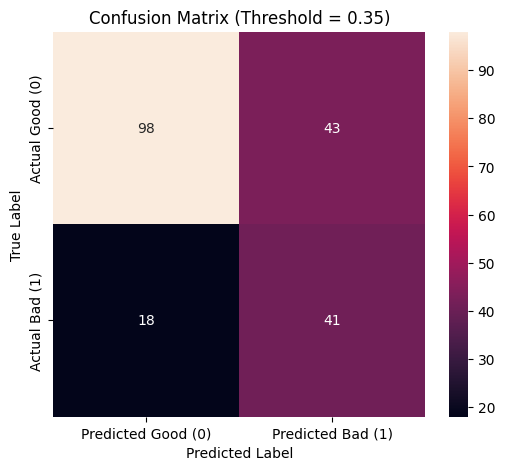


Classification Report (Threshold = 0.35):
              precision    recall  f1-score   support

           0       0.84      0.70      0.76       141
           1       0.49      0.69      0.57        59

    accuracy                           0.69       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.74      0.69      0.71       200



In [38]:
# Define a new threshold (0.35 as suggested in strategic recommendations)
new_threshold = 0.35

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = model.predict_proba(X_test_pca)[:, 1]

# Apply the new threshold to get new predictions
y_pred_tuned = (y_pred_proba >= new_threshold).astype(int)

print(f"Predictions with a new threshold of {new_threshold}:")

# Compute and display the new confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d',
            xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
            yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Threshold = {new_threshold})')
plt.show()

print(f"\nClassification Report (Threshold = {new_threshold}):")
print(classification_report(y_test, y_pred_tuned))

### **Threshold Tuning Analysis (0.50 → 0.35)**

To improve detection of high-risk borrowers, the classification threshold was reduced
from 0.50 to 0.35. This adjustment shifts the model’s priority from overall accuracy
toward improved detection of defaulters.


### **Performance Comparison**

| Metric | Threshold 0.50 | Threshold 0.35 | Change |
|--------|----------------|----------------|--------|
| True Positives (TP) | 31 | 41 | +10 |
| False Negatives (FN) | 28 | 18 | −10 |
| False Positives (FP) | 18 | 43 | +25 |
| Recall (Class 1) | 0.53 | 0.69 | +0.16 |
| Overall Accuracy | 0.77 | 0.69 | −0.08 |

---
### **Statistical Interpretation**

#### **1. Increased Sensitivity (Recall)**

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$\text{New Recall} = \frac{41}{41 + 18} = 0.69$$

- **Recall** improved by 16 percentage points.  
The model now detects 69\% of actual defaulters compared to 53\% previously.

- False Negatives decreased:
$28 \rightarrow 18$

This represents 10 additional high-risk borrowers correctly identified.


#### **2. Decline in Precision**

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{New Precision} = \frac{41}{41 + 43} = 0.49$$

- Precision declined from `0.63` to `0.49`, indicating that only $49$% of applicants classified as “Bad” are truly high risk.

- False Positives increased: $18 \rightarrow 43$

Thus, 25 additional creditworthy customers are now incorrectly flagged.

---

### **Economic Implications**

In credit risk modeling, not all classification errors carry equal cost. Model accuracy drops from $0.77$ to $0.69$ but in credit risk, all errors are not equal.


- False Negative (FN): Lending to a defaulter  
- False Positive (FP): Rejecting a creditworthy applicant  

Assume:

- Average loss per default = \$10,000  
- Average profit per good loan = \$1,000  

### **Financial Effect of Threshold Adjustment**

Prevented Defaults:
$$\text10 \times 10,000 = 100,000$$

Lost Profitable Loans:
$$\text25 \times 1,000 = 25,000$$

Net Financial Impact:
$$\text100,000 - 25,000 = 75,000$$

Despite a reduction in overall accuracy, the model produces a net economic gain under these assumptions.

---

### **Interpretation in Context of ROC and PR Curves**

- **The ROC curve (AUC = 0.80)** indicated strong class separability, suggesting threshold flexibility.

- **The Precision–Recall curve (AUC = 0.61)** predicted the observed trade-off: as recall increases, precision declines.

Thus, the empirical results are consistent with theoretical expectations.

---

### **Conclusion of Threshold Experiment**

Lowering the threshold transformed the model into a more risk-averse classifier:

- Reduced exposure to costly defaults
- Increased rejection of some creditworthy borrowers
- Demonstrated that accuracy alone is not an appropriate metric in imbalanced financial datasets

The optimal threshold should therefore be selected using a cost-sensitive framework:

$$\text{Total Expected Cost} =
(FN \times \text{Cost}_{FN}) +
(FP \times \text{Cost}_{FP})
$$

This aligns statistical modeling with financial decision-making and reflects modern best practices in credit risk analytics.